# 01 — EDA & Dataset Overview

Exploratory data analysis for the thesis project.  
- Prices, returns, volatility
- Rolling correlations
- Distribution tests
- Stationarity (ADF)


In [1]:
import sys, os
# Add project root to path
ROOT = r'D:\clode9'
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from thesis_app.pipeline import load_config, build_paths, fetch_prices, compute_returns, fisher_z, rolling_corr

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (13, 5)

cfg = load_config(os.path.join(ROOT, 'config.yaml'))
paths = build_paths(cfg['base_dir'])
print('Config loaded. base_dir =', cfg['base_dir'])

Config loaded. base_dir = D:/clode9


In [2]:
# ─── Load data ────────────────────────────────────────────────────
tickers = cfg['assets']['crypto'] + cfg['assets']['traditional']
prices = fetch_prices(paths, tickers, cfg['start_date'], cfg.get('end_date'))
rets   = compute_returns(paths, prices)

print(f'Prices shape: {prices.shape}   {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Returns shape: {rets.shape}')
rets.tail(3)

Loaded prices from cache: D:/clode9\data\raw\prices.csv
Prices shape: (2976, 7)   2017-11-09 → 2026-02-27
Returns shape: (2975, 7)


,BTC-USD,ETH-USD,GLD,SLV,UUP,^GSPC,^IXIC
Date,,,,,,,
2026-02-25,0.058788,0.103305,-0.002510,0.012066,-0.001107,0.008103,0.012535
2026-02-26,-0.007479,-0.013640,0.008539,0.005109,0.000738,-0.005380,-0.011892
2026-02-27,-0.019912,-0.038195,0.000000,0.000000,0.000000,0.000000,0.000000


In [3]:
# ─── Descriptive stats ────────────────────────────────────────────
desc = rets.describe().T
desc['skew'] = rets.skew()
desc['kurt'] = rets.kurtosis()
desc.style.format('{:.4f}').background_gradient(axis=0, subset=['std','skew','kurt'])

,count,mean,std,min,25%,50%,75%,max,skew,kurt
BTC-USD,2975.0000,0.0007,0.0355,-0.4647,-0.0138,0.0007,0.0154,0.2251,-0.7303,13.3514
ETH-USD,2975.0000,0.0006,0.0460,-0.5507,-0.0191,0.0005,0.0214,0.2949,-0.7413,10.7541
GLD,2975.0000,0.0005,0.0085,-0.1084,-0.0018,0.0000,0.0035,0.0616,-0.8765,14.9140
SLV,2975.0000,0.0005,0.0175,-0.3360,-0.0038,0.0000,0.0054,0.0875,-2.9142,55.7611
UUP,2975.0000,0.0001,0.0037,-0.0326,-0.0012,0.0000,0.0015,0.0371,-0.0231,8.6969
^GSPC,2975.0000,0.0003,0.0102,-0.1277,-0.0016,0.0000,0.0037,0.0909,-0.7473,22.7825
^IXIC,2975.0000,0.0004,0.0124,-0.1315,-0.0021,0.0000,0.0051,0.1148,-0.4682,12.8037


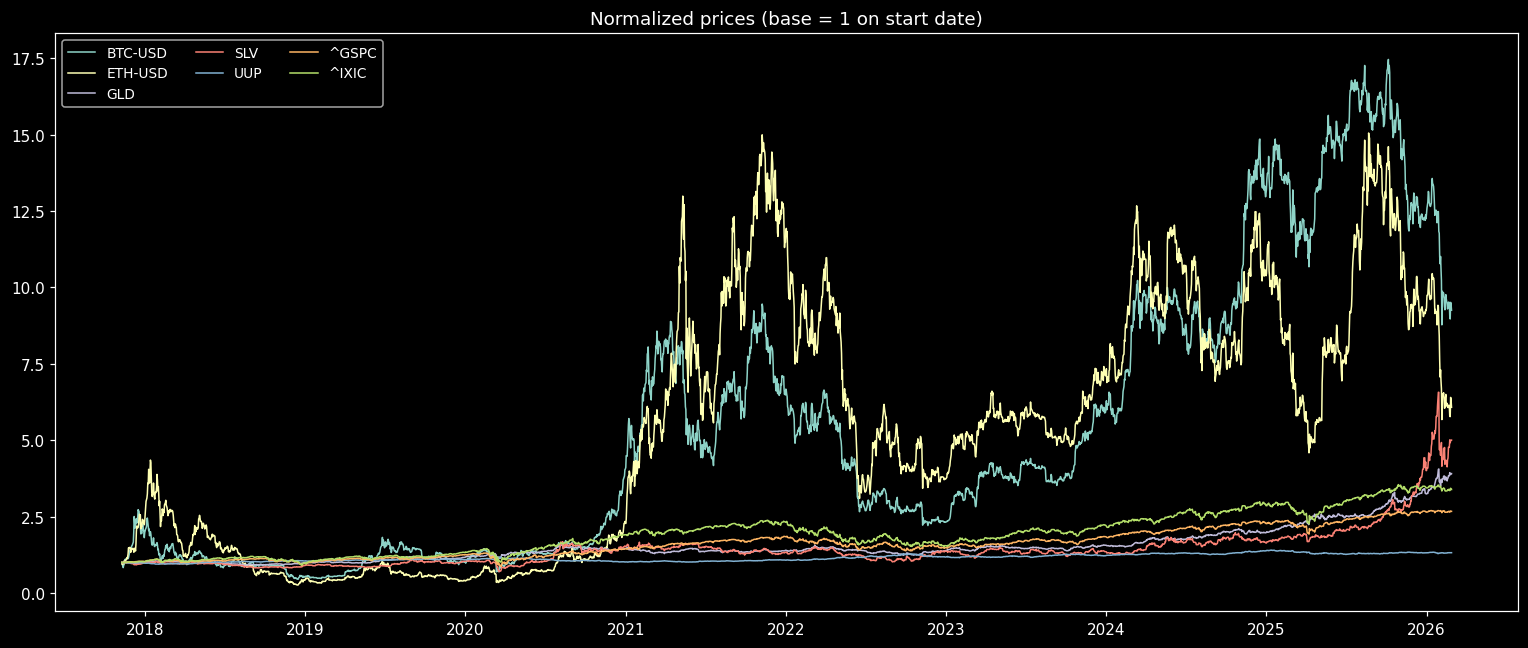

In [4]:
# ─── Normalized price series ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for c in prices.columns:
    ax.plot(prices.index, prices[c] / prices[c].iloc[0], label=c, lw=1)
ax.set_title('Normalized prices (base = 1 on start date)', fontsize=12)
ax.legend(ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'eda_normalized_prices.png'), dpi=130)
plt.show()

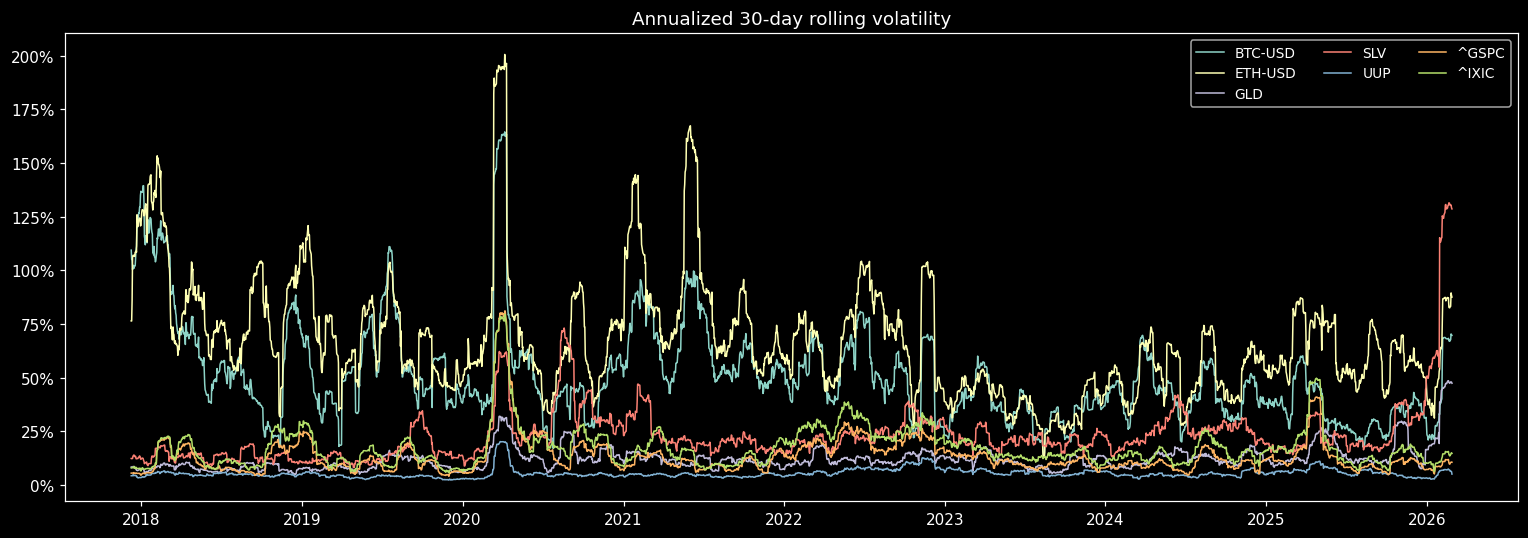

In [5]:
# ─── Rolling volatility ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for c in rets.columns:
    rv = rets[c].rolling(30).std() * np.sqrt(252)  # annualized
    ax.plot(rv.index, rv, label=c, lw=1)
ax.set_title('Annualized 30-day rolling volatility', fontsize=12)
ax.legend(ncol=3, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'eda_rolling_vol.png'), dpi=130)
plt.show()

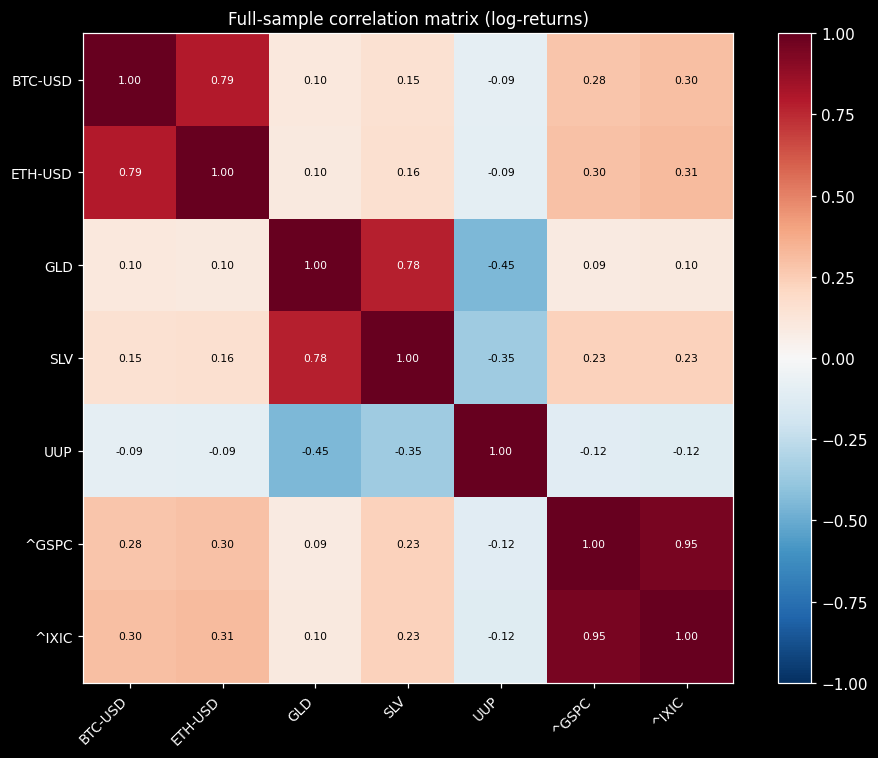

         BTC-USD  ETH-USD    GLD    SLV    UUP  ^GSPC  ^IXIC
BTC-USD    1.000    0.792  0.102  0.151 -0.091  0.278  0.298
ETH-USD    0.792    1.000  0.099  0.156 -0.094  0.296  0.314
GLD        0.102    0.099  1.000  0.776 -0.447  0.092  0.099
SLV        0.151    0.156  0.776  1.000 -0.354  0.230  0.233
UUP       -0.091   -0.094 -0.447 -0.354  1.000 -0.117 -0.118
^GSPC      0.278    0.296  0.092  0.230 -0.117  1.000  0.951
^IXIC      0.298    0.314  0.099  0.233 -0.118  0.951  1.000


In [6]:
# ─── Full-sample correlation heatmap ──────────────────────────────
corr = rets.corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.values[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax)
ax.set_title('Full-sample correlation matrix (log-returns)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'eda_corr_heatmap.png'), dpi=130)
plt.show()
print(corr.round(3))

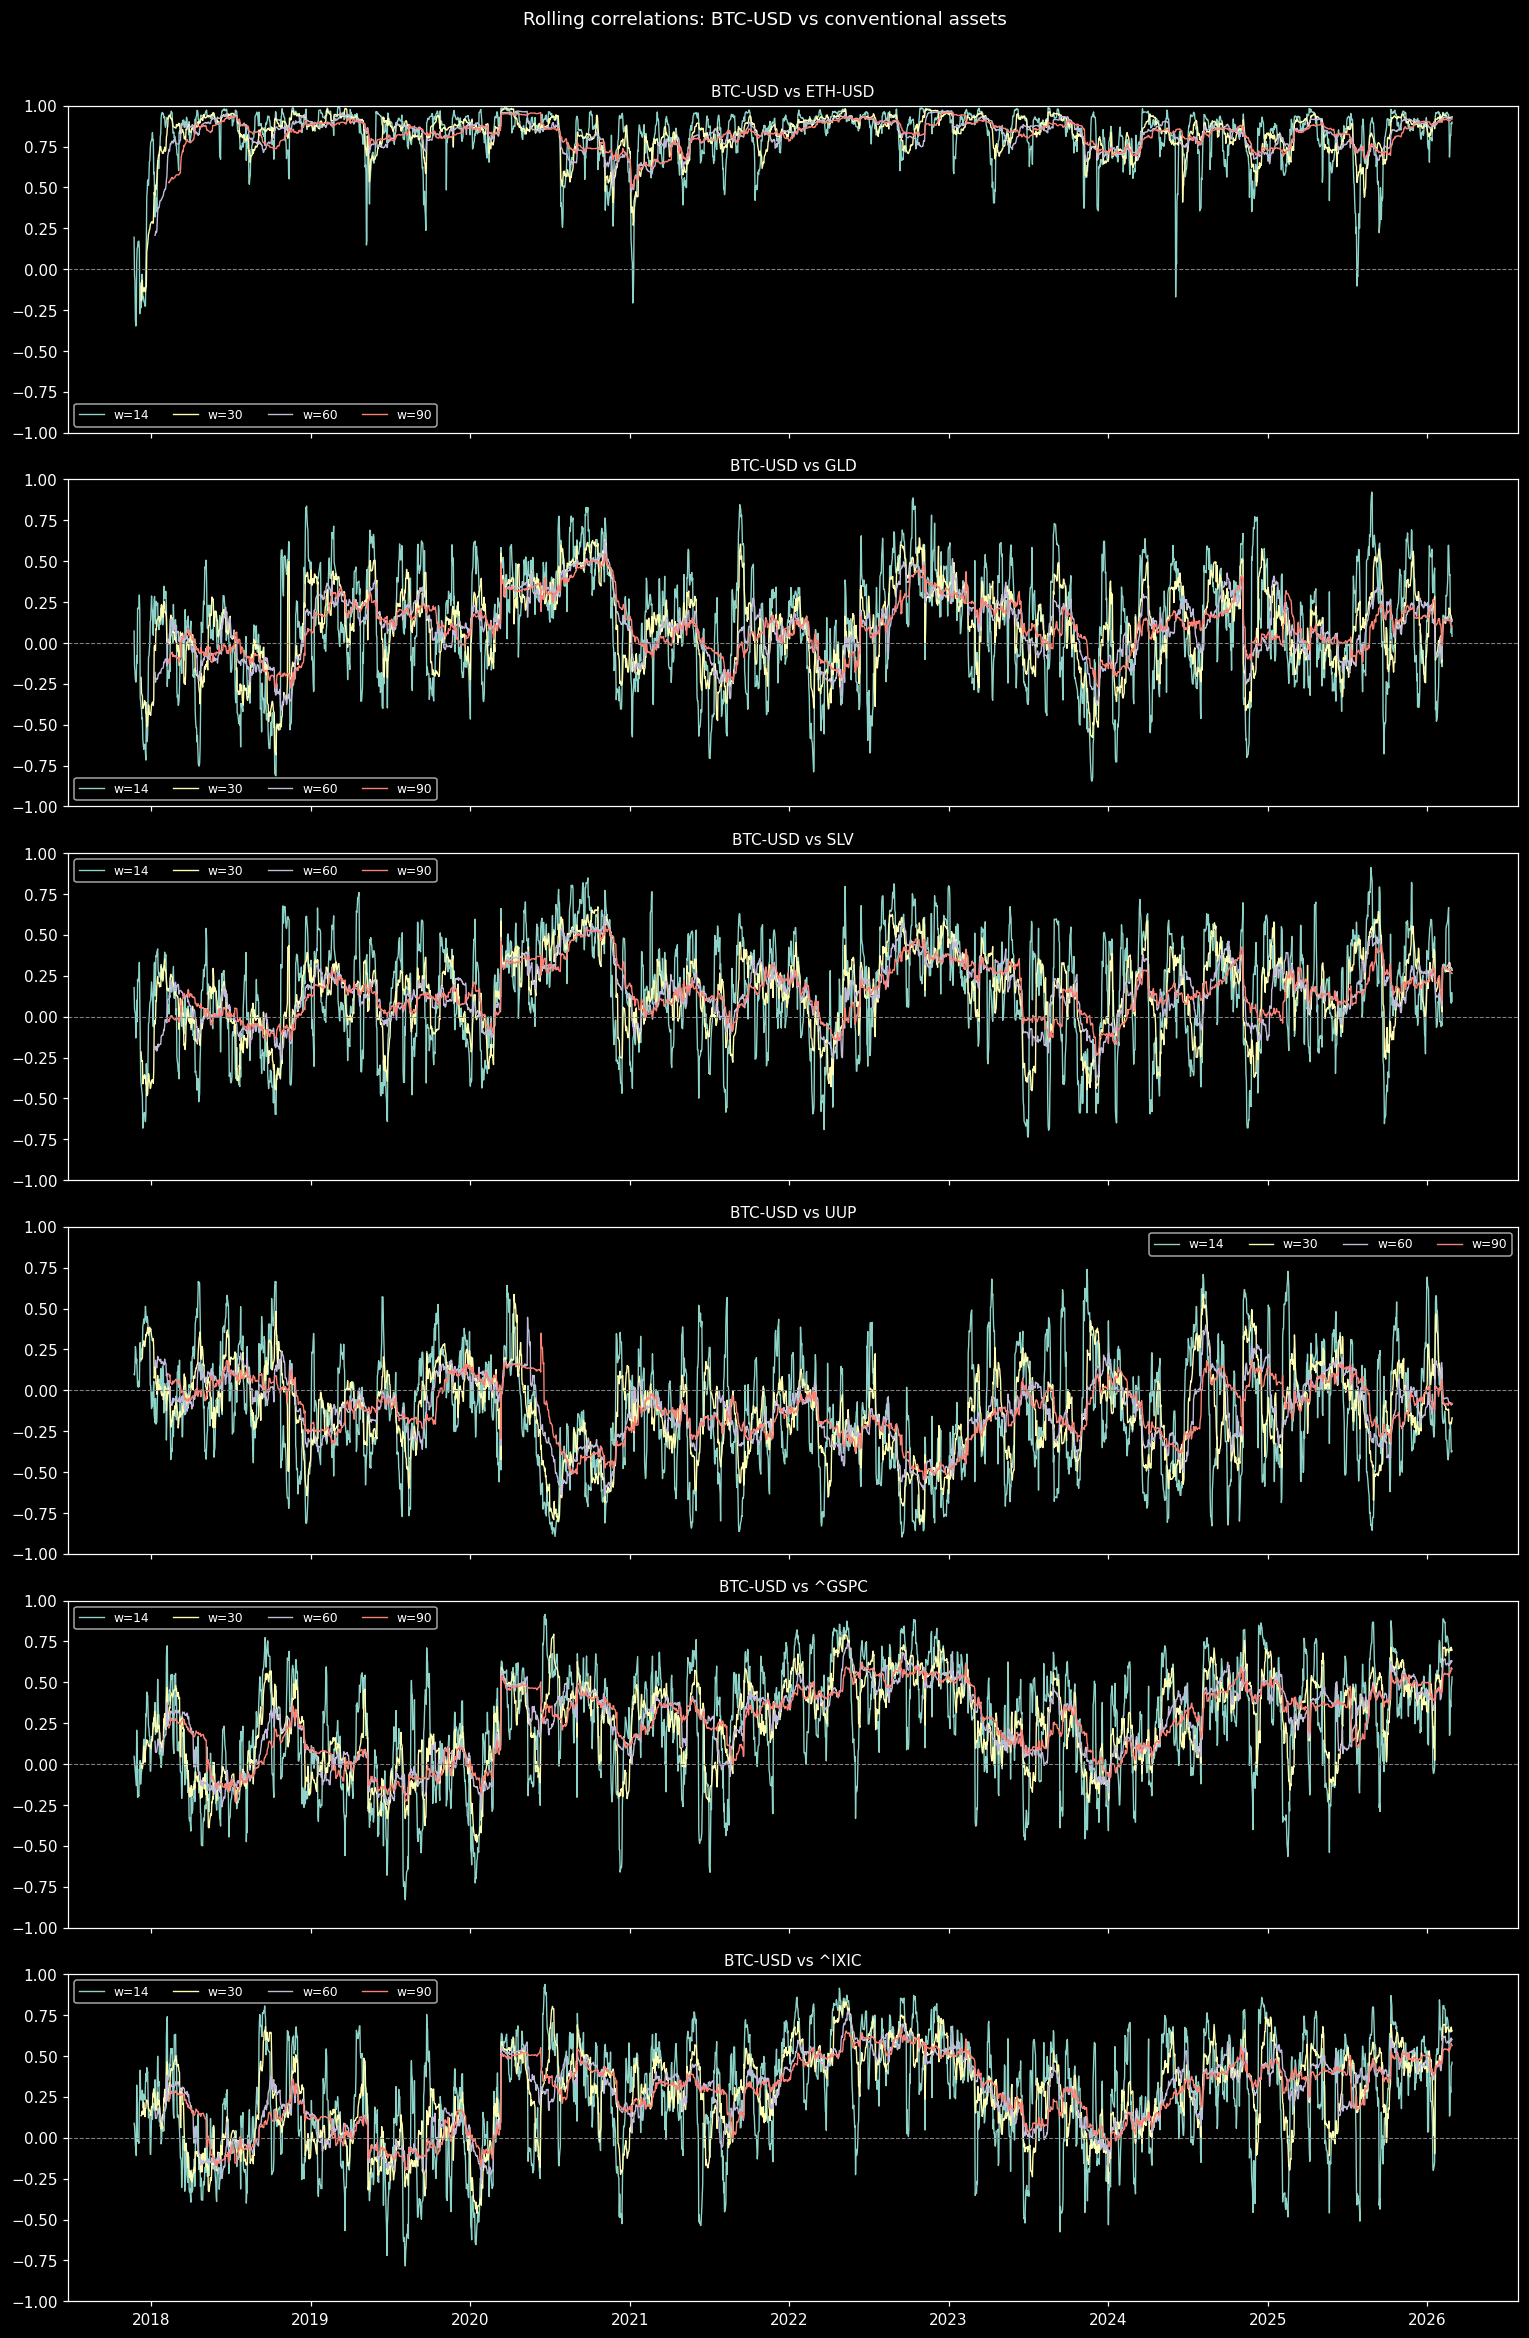

In [7]:
# ─── Rolling correlation: BTC vs all ──────────────────────────────
base = cfg['base_asset']
others = [c for c in rets.columns if c != base]
windows = cfg['rolling_windows']

fig, axes = plt.subplots(len(others), 1, figsize=(14, 3.5 * len(others)), sharex=True)
if len(others) == 1:
    axes = [axes]

for ax, other in zip(axes, others):
    for w in windows:
        rc = rolling_corr(rets[base], rets[other], w).dropna()
        ax.plot(rc.index, rc, label=f'w={w}', lw=0.9)
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.set_title(f'{base} vs {other}', fontsize=10)
    ax.legend(ncol=4, fontsize=8)
    ax.set_ylim(-1, 1)

plt.suptitle(f'Rolling correlations: {base} vs conventional assets', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'eda_rolling_corr_all.png'), dpi=130, bbox_inches='tight')
plt.show()

In [8]:
# ─── ADF stationarity test on rolling correlations ────────────────
from statsmodels.tsa.stattools import adfuller

rows = []
for other in others:
    for w in windows:
        rc = rolling_corr(rets[base], rets[other], w).dropna()
        adf_stat, adf_p, _, _, _, _ = adfuller(rc, maxlag=10, autolag='AIC')
        rows.append({
            'pair': f'{base} vs {other}',
            'window': w,
            'ADF_stat': round(adf_stat, 3),
            'p_value': round(adf_p, 4),
            'Stationary (5%)': 'Yes' if adf_p < 0.05 else 'No'
        })

adf_df = pd.DataFrame(rows)
print(adf_df.to_string(index=False))

              pair  window  ADF_stat  p_value Stationary (5%)
BTC-USD vs ETH-USD      14   -10.752   0.0000             Yes
BTC-USD vs ETH-USD      30    -7.902   0.0000             Yes
BTC-USD vs ETH-USD      60    -5.869   0.0000             Yes
BTC-USD vs ETH-USD      90    -4.433   0.0003             Yes
    BTC-USD vs GLD      14   -11.242   0.0000             Yes
    BTC-USD vs GLD      30    -6.659   0.0000             Yes
    BTC-USD vs GLD      60    -4.818   0.0001             Yes
    BTC-USD vs GLD      90    -3.680   0.0044             Yes
    BTC-USD vs SLV      14   -11.254   0.0000             Yes
    BTC-USD vs SLV      30    -7.013   0.0000             Yes
    BTC-USD vs SLV      60    -4.633   0.0001             Yes
    BTC-USD vs SLV      90    -3.723   0.0038             Yes
    BTC-USD vs UUP      14   -11.238   0.0000             Yes
    BTC-USD vs UUP      30    -6.621   0.0000             Yes
    BTC-USD vs UUP      60    -4.550   0.0002             Yes
    BTC-

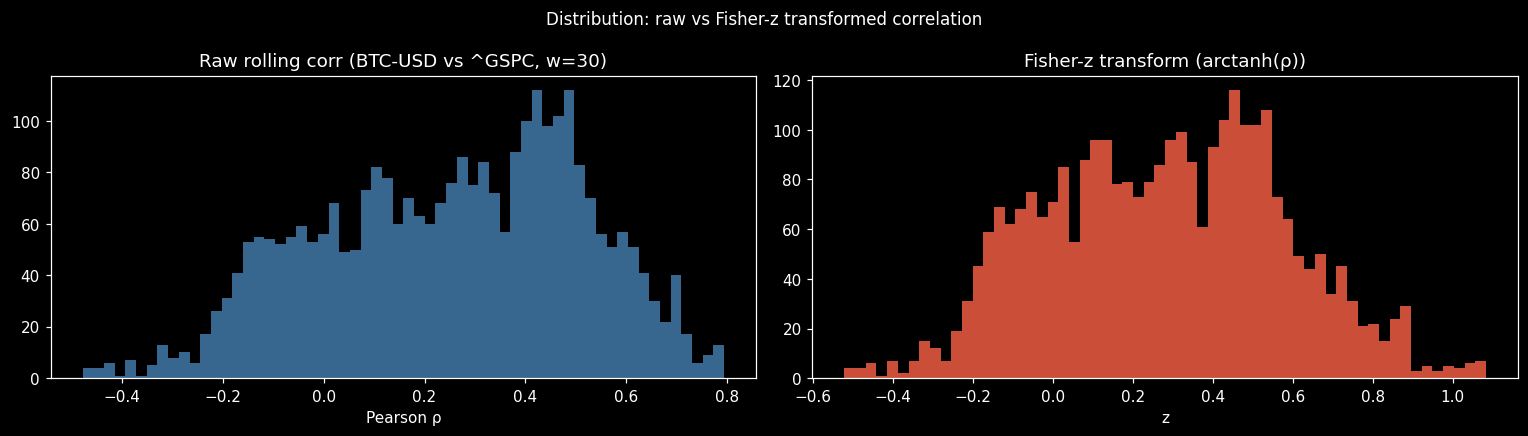

Shapiro-Wilk p-value  |  raw corr: 0.0000  |  Fisher-z: 0.0000
(Higher p → more Gaussian → Fisher-z is preferred for ML)


In [9]:
# ─── Fisher-z transform illustration ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
other = '^GSPC'
w = 30
rc = rolling_corr(rets[base], rets[other], w).dropna()
fz = fisher_z(rc)

axes[0].hist(rc.dropna(), bins=60, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].set_title(f'Raw rolling corr ({base} vs {other}, w={w})')
axes[0].set_xlabel('Pearson ρ')

axes[1].hist(fz.dropna(), bins=60, color='tomato', alpha=0.8, edgecolor='none')
axes[1].set_title(f'Fisher-z transform (arctanh(ρ))')
axes[1].set_xlabel('z')

plt.suptitle('Distribution: raw vs Fisher-z transformed correlation', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'eda_fisher_transform.png'), dpi=130)
plt.show()

# Normality tests
_, p_raw = stats.shapiro(rc.dropna().sample(min(5000, len(rc)), random_state=42))
_, p_fz  = stats.shapiro(fz.dropna().sample(min(5000, len(fz)), random_state=42))
print(f'Shapiro-Wilk p-value  |  raw corr: {p_raw:.4f}  |  Fisher-z: {p_fz:.4f}')
print('(Higher p → more Gaussian → Fisher-z is preferred for ML)')

In [10]:
print('✅ EDA complete. All figures saved to:', paths.figures)

✅ EDA complete. All figures saved to: D:/clode9\outputs\figures
